# Model Tuning

## Objectives:  
Tune parameters for:
- **Content-based TF-IDF model**  
- **Hybrid model (SVD + Content Similarity)**  

This notebook builds upon data preprocessing and TF-IDF feature extraction from previous steps.

In [2]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Project-specific imports
sys.path.append(os.path.abspath(".."))
from src.evaluation.metrics import tune_tfidf_params, tune_hybrid_weights
from src.recommender.hybrid import SVDHybridRecommender
from src.utils.preprocessing import (
    load_clean_data,
    preprocess_content_text,
    get_users_for_eval,
    prepare_matrices
)
from src.utils.mappings import get_toeic_part_mapping, get_subject_categories

# Set plot style and random seed
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="viridis")

## 1. Load & Prepare Data
- Load **cleaned lectures** & **merged user interaction** data.
- Aggregate bundle-level features (e.g., part, tags, question count).
- Create a `content_text` field for TF-IDF vectorization.

In [4]:
# Load data
lectures_df, merged_df = load_clean_data()
print(f"Lectures: {len(lectures_df)}, Interactions: {len(merged_df)}")

merged_df.head()

Loading from paths:
Lectures: c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\data\cleaned\cleaned_lectures.csv
Merged: c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\data\cleaned\merged_cleaned_data.csv
Successfully loaded 1021 lectures and 117167 interactions
Lectures: 1021, Interactions: 117167


,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id,bundle_id,explanation_id,correct_answer,part,tags,deployed_at,is_correct,tag_difficulty
0,2018-03-25 09:57:07.112,1,q8098,b,12000,u145242,b5569,e5569,b,1,5;2;182,2017-12-29 15:06:23.093,True,0.665909
1,2018-03-25 09:57:35.061,2,q8074,d,25000,u145242,b5545,e5545,c,1,11;7;183,2018-05-18 08:57:02.552,False,0.628323
2,2018-03-25 09:57:59.724,3,q176,b,22000,u145242,b176,e176,d,1,6;7;183,2017-12-29 14:53:43.800,False,0.641848
3,2018-03-25 09:58:19.710,4,q1279,c,17000,u145242,b1279,e1279,c,2,24;26;182;184,2019-10-17 02:58:38.714,True,0.681122
4,2018-03-25 09:59:03.593,5,q2067,a,13333,u145242,b1623,e1623,b,3,52;183;184,2019-03-12 02:28:10.338,False,0.641035


In [5]:
# Prepare bundle features (from notebooks/02_tf_idf.ipynb)
bundle_info = merged_df.groupby('bundle_id').agg({
    'part': 'first',  # Use the first part value for each bundle
    'tags': lambda x: ';'.join(set(str(i) for i in x if pd.notna(i))),  # Combine unique tags
    'question_id': lambda x: len(set(x))  # Count unique questions per bundle
}).reset_index()

# Edit columns for clarity
bundle_info.columns = ['bundle_id', 'part', 'tags', 'question_count']

# Map part numbers to descriptive names
part_names = get_toeic_part_mapping()
bundle_info['part_name'] = bundle_info['part'].map(part_names)

# Derive subject category from tags
bundle_info['subject_category'] = bundle_info['tags'].apply(
    lambda x: get_subject_categories(x)[0] if get_subject_categories(x) else "General"
)

# Combine part name, subject category & tags into a single text field
bundle_info['content_text'] = (
    bundle_info['part_name'].fillna('') + ' ' +
    bundle_info['subject_category'].fillna('') + ' ' +
    bundle_info['tags'].fillna('')
)

# Preprocess the combined text for TF-IDF vectorization
bundle_info['content_text'] = bundle_info['content_text'].apply(preprocess_content_text)

# Preview the resulting bundle features
bundle_info.head()

,bundle_id,part,tags,question_count,part_name,subject_category,content_text
0,b1,1,1;2;179;181,1,Part 1: Listening - Photographs,grammar_advanced,part 1: listening - photographs grammar_advanc...
1,b10,1,17;7;182,1,Part 1: Listening - Photographs,grammar_advanced,part 1: listening - photographs grammar_advanc...
2,b100,1,22;2;181,1,Part 1: Listening - Photographs,grammar_advanced,part 1: listening - photographs grammar_advanc...
3,b1000,2,24;33;182;183,1,Part 2: Listening - Question-Response,grammar_intermediate,part 2: listening - question-response grammar_...
4,b1001,2,34;35;182;183,1,Part 2: Listening - Question-Response,grammar_intermediate,part 2: listening - question-response grammar_...


In [6]:
# Step Extract numeric IDs from 'explanation_id' → from merged_df
lecture_to_bundle = merged_df[['bundle_id', 'explanation_id']].dropna().copy()
lecture_to_bundle['lecture_numeric_id'] = lecture_to_bundle['explanation_id'].str.extract(r'(\d+)')

# Extract numeric IDs from 'lecture_id' → from lectures_df
lectures_clean = lectures_df[['lecture_id', 'video_minutes']].dropna().copy()
lectures_clean['lecture_numeric_id'] = lectures_clean['lecture_id'].astype(str).str.extract(r'(\d+)')

# Join on numeric ID
merged = pd.merge(
    lecture_to_bundle,
    lectures_clean,
    on='lecture_numeric_id',
    how='left'
)

# Aggregate average durations per bundle
avg_durations = (
    merged.dropna(subset=['video_minutes'])
    .groupby('bundle_id')['video_minutes']
    .mean()
    .reset_index()
)

# Merge into bundle_info
bundle_info = bundle_info.drop(columns='video_minutes', errors='ignore')
bundle_info = bundle_info.merge(avg_durations, on='bundle_id', how='left')
bundle_info['video_minutes'] = bundle_info['video_minutes'].fillna(0).round(2)

bundle_info.tail()

,bundle_id,part,tags,question_count,part_name,subject_category,content_text,video_minutes
8255,b995,2,30;28;29;182;181,1,Part 2: Listening - Question-Response,grammar_intermediate,part 2: listening - question-response grammar_...,0.0
8256,b996,2,27;24;41;182;181,1,Part 2: Listening - Question-Response,grammar_intermediate,part 2: listening - question-response grammar_...,0.0
8257,b997,2,179;44;49;183;181,1,Part 2: Listening - Question-Response,grammar_intermediate,part 2: listening - question-response grammar_...,0.0
8258,b998,2,24;43;183;184,1,Part 2: Listening - Question-Response,grammar_intermediate,part 2: listening - question-response grammar_...,0.0
8259,b999,2,36;37;182;183,1,Part 2: Listening - Question-Response,grammar_intermediate,part 2: listening - question-response grammar_...,0.0


In [7]:
bundle_info[bundle_info['video_minutes'] > 0].head() # To check if duration is not always zero

,bundle_id,part,tags,question_count,part_name,subject_category,content_text,video_minutes
858,b1246,2,36;37;183;181,1,Part 2: Listening - Question-Response,grammar_intermediate,part 2: listening - question-response grammar_...,7.67
859,b1247,2,28;37;183;184,1,Part 2: Listening - Question-Response,grammar_intermediate,part 2: listening - question-response grammar_...,8.83
860,b1248,2,30;31;42;185;183,1,Part 2: Listening - Question-Response,grammar_intermediate,part 2: listening - question-response grammar_...,6.87
861,b1249,2,44;45;185;183,1,Part 2: Listening - Question-Response,grammar_intermediate,part 2: listening - question-response grammar_...,7.00
863,b1250,2,24;41;183;185,1,Part 2: Listening - Question-Response,grammar_intermediate,part 2: listening - question-response grammar_...,7.30


In [8]:
# See how many bundles got matched to lectures with duration
print(f"Bundles with duration: {bundle_info[bundle_info['video_minutes'] > 0].shape[0]}")
print(f"Total bundles: {bundle_info.shape[0]}")

Bundles with duration: 515
Total bundles: 8260


## 2. TF-IDF Parameter Tuning
Here I define a **grid of TF-IDF parameters** and test them using our evaluation functions.

Evaluation Metrics:
- **Precision@10**
- **Recall@10**

In [9]:
# Define grid of TF-IDF hyperparameters for tuning
tfidf_params_grid = [
    {'max_features': 3000, 'stop_words': 'english', 'ngram_range': (1, 1), 'min_df': 0.01, 'max_df': 0.95},  # Unigrams only
    {'max_features': 5000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.01, 'max_df': 0.95},  # Unigrams + bigrams
    {'max_features': 7000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.005, 'max_df': 0.90}, # Lower min_df, tighter max_df
    {'max_features': 10000, 'stop_words': 'english', 'ngram_range': (1, 3), 'min_df': 0.005, 'max_df': 0.85} # Include trigrams, broader vocab
]

# Build a recommendation function using cosine similarity over TF-IDF matrix
def build_recommend_fn(tfidf_matrix, vectorizer, min_similarity=0.1):
    sim = cosine_similarity(tfidf_matrix)  # Compute pairwise similarity between bundles
    indices = pd.Series(bundle_info.index, index=bundle_info['bundle_id'])  # Map bundle_id to matrix index

    def recommend_fn(user_id, k=10):
        try:
            # Get bundles the user has interacted with
            user_history = merged_df[merged_df['user_id'] == user_id]
            seen_bundles = set(user_history['bundle_id'].unique())
            rec_scores = {}

            # Aggregate similarity scores from seen bundles to unseen ones
            for b in seen_bundles:
                if b not in indices:
                    continue
                idx = indices[b]
                for i, score in enumerate(sim[idx]):
                    b_id = bundle_info.iloc[i]['bundle_id']
                    if b_id not in seen_bundles and score >= min_similarity:
                        rec_scores[b_id] = rec_scores.get(b_id, 0) + score

            # Normalize & rank recommendations
            if not rec_scores:
                return []
            max_score = max(rec_scores.values())
            rec_scores = {k: v / max_score for k, v in rec_scores.items()}
            top_bundles = sorted(rec_scores.items(), key=lambda x: x[1], reverse=True)[:k]

            return top_bundles  # Return top-k (bundle_id, score) pairs

        except Exception as e:
            print(f"Error in recommend_fn for user {user_id}: {str(e)}")
            return []

    return recommend_fn

Testing TF-IDF params: {'max_features': 3000, 'stop_words': 'english', 'ngram_range': (1, 1), 'min_df': 0.01, 'max_df': 0.95}
{'params': "{'max_features': 3000, 'stop_words': 'english', 'ngram_range': (1, 1), 'min_df': 0.01, 'max_df': 0.95}", 'precision': np.float64(0.0), 'recall': np.float64(0.0)}
Testing TF-IDF params: {'max_features': 5000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.01, 'max_df': 0.95}
{'params': "{'max_features': 5000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.01, 'max_df': 0.95}", 'precision': np.float64(0.0), 'recall': np.float64(0.0)}
Testing TF-IDF params: {'max_features': 7000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.005, 'max_df': 0.9}
{'params': "{'max_features': 7000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.005, 'max_df': 0.9}", 'precision': np.float64(0.0), 'recall': np.float64(0.0)}
Testing TF-IDF params: {'max_features': 10000, 'stop_words': 'english', 'ngram_range': (1, 3), 'min_

c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\src\evaluation\metrics.py:141: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


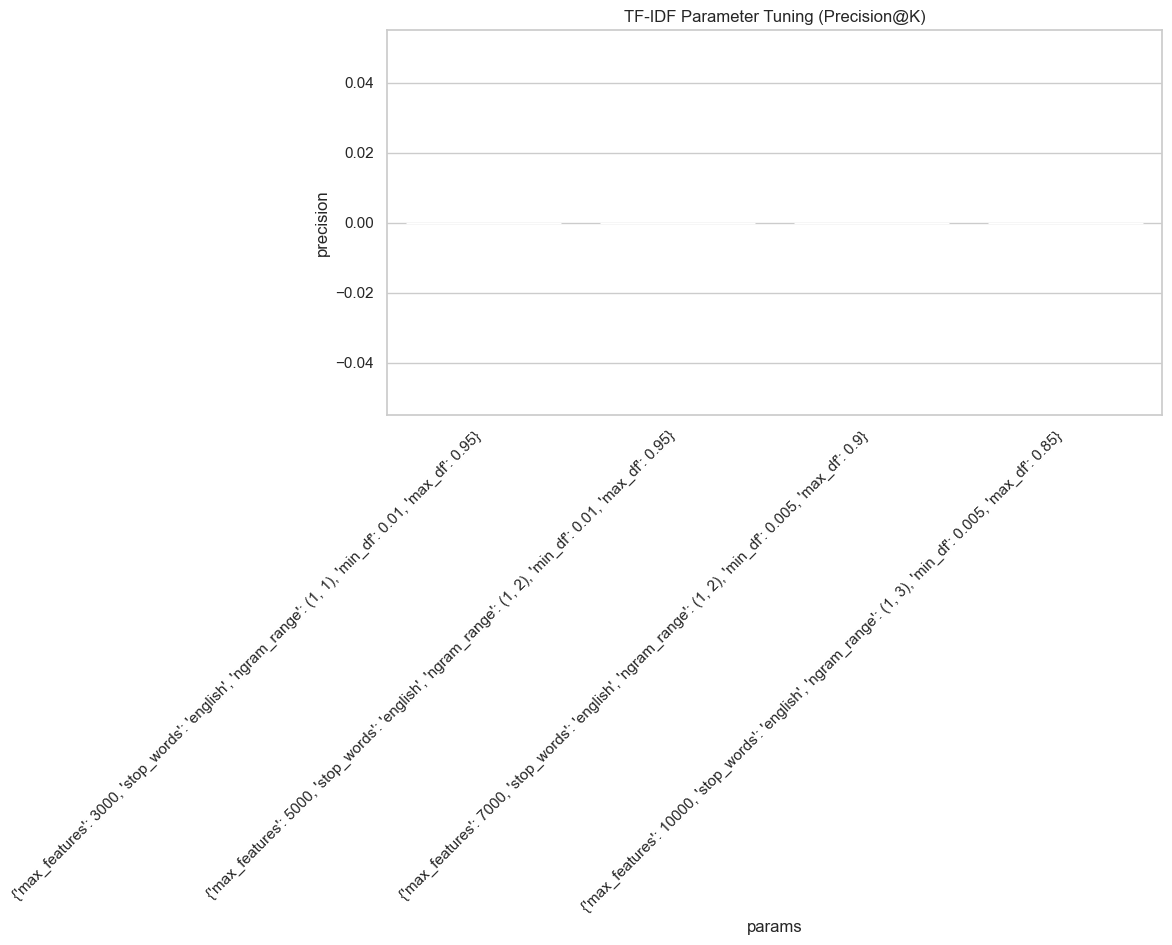

In [10]:
# Returns list of bundles a user has interacted with (used as ground truth)
def get_relevant_fn(user_id):
    return merged_df[merged_df['user_id'] == user_id]['bundle_id'].unique().tolist()

# Run TF-IDF parameter tuning and evaluate recommendation performance
tfidf_results = tune_tfidf_params(
    param_grid=tfidf_params_grid,  # Grid of TF-IDF configurations to test
    vectorizer_class=TfidfVectorizer,  # TF-IDF vectorizer class
    X_raw=bundle_info['content_text'],  # Raw text data for vectorization
    y_true_fn=lambda: get_users_for_eval(merged_df),  # List of users to evaluate
    recommend_fn_builder=build_recommend_fn,  # Builds recommender using TF-IDF matrix
    ground_truth_fn=get_relevant_fn,  # Provides actual bundles seen by each user
    k=10,  # Number of top recommendations to evaluate
    output_path="../data/cleaned/tfidf_tuning_results_updated.csv"  # Save results to CSV
)

## 3. Hybrid Model Tuning (SVD + Content)
I test different **α (weight)** values that balance:
- **Collaborative Filtering (SVD)**
- **Content-based Similarity (TF-IDF cosine)**

In [11]:
# Prepare user-item interaction matrices for training and testing
train_matrix, test_matrix, user_map, item_map = prepare_matrices(merged_df)
# Create reverse lookup: matrix index → original item ID
reverse_item_map = {v: k for k, v in item_map.items()}

In [12]:
# Define range of alpha values for blending content-based and collaborative scores
alpha_range = [round(w, 2) for w in np.arange(0.1, 1.1, 0.05)]  # 0.1 to 1.0 in 0.05 steps
# Generate train/test user-item interaction matrices and ID mappings
train_matrix, test_matrix, user_map, item_map = prepare_matrices(merged_df)

# Compute content-based similarity between items using TF-IDF (unigrams only)
content_similarity = cosine_similarity(
    TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1, 1))
    .fit_transform(bundle_info['content_text'])
)

Testing hybrid weight: 0.1


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\src\evaluation\metrics.py:163: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  model.fit(train_matrix, content_sim)
c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 

{'weight': np.float64(0.1), 'precision@10': 0.007515923566878976, 'recall@10': 0.0018884836289589004, 'rmse': np.float64(2.344688130822845)}
Testing hybrid weight: 0.15


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generate

{'weight': np.float64(0.15), 'precision@10': 0.007643312101910824, 'recall@10': 0.0018926196203560381, 'rmse': np.float64(2.344688130822845)}
Testing hybrid weight: 0.2


...

{'weight': np.float64(0.95), 'precision@10': 0.03133757961783442, 'recall@10': 0.0454353712086996, 'rmse': np.float64(2.344688130822845)}
Testing hybrid weight: 1.0


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generate

{'weight': np.float64(1.0), 'precision@10': 0.04433121019108286, 'recall@10': 0.07348578335766467, 'rmse': np.float64(2.344688130822845)}
Testing hybrid weight: 1.05


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generate

{'weight': np.float64(1.05), 'precision@10': 0.03490445859872614, 'recall@10': 0.0554532581965485, 'rmse': np.float64(2.344688130822845)}


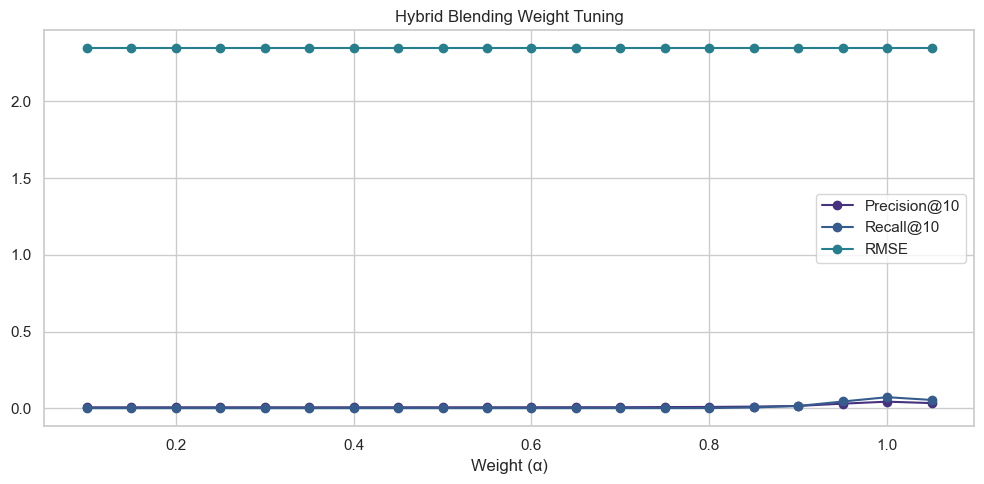

In [13]:
# Run hybrid model tuning across different alpha weights
hybrid_results = tune_hybrid_weights(
    weights=alpha_range,  # List of blending weights for content vs. collaborative scores
    model_class=SVDHybridRecommender,  # Hybrid recommender class (e.g., SVD + content-based)
    train_matrix=train_matrix,  # User-item training interactions
    content_sim=content_similarity,  # Precomputed item-item content similarity matrix
    test_matrix=test_matrix,  # User-item test interactions for evaluation
    precision_k=10,  # Evaluate top-10 recommendations
    output_path="../data/cleaned/hybrid_tuning_results_updated.csv",  # Save results to CSV
    user_map=user_map,  # Mapping: user_id → matrix index
    item_map=item_map,  # Mapping: item_id → matrix index
    reverse_item_map=reverse_item_map  # Reverse mapping: matrix index → item_id
)

## 4. Visualizing Results
Compare **Precision@10**, **Recall@10** and **RMSE** across different weights.

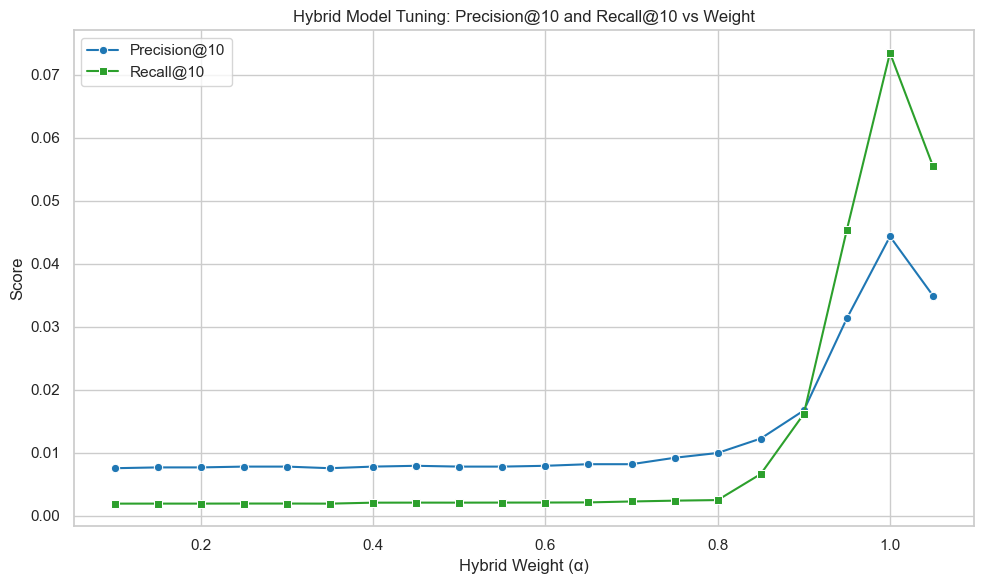

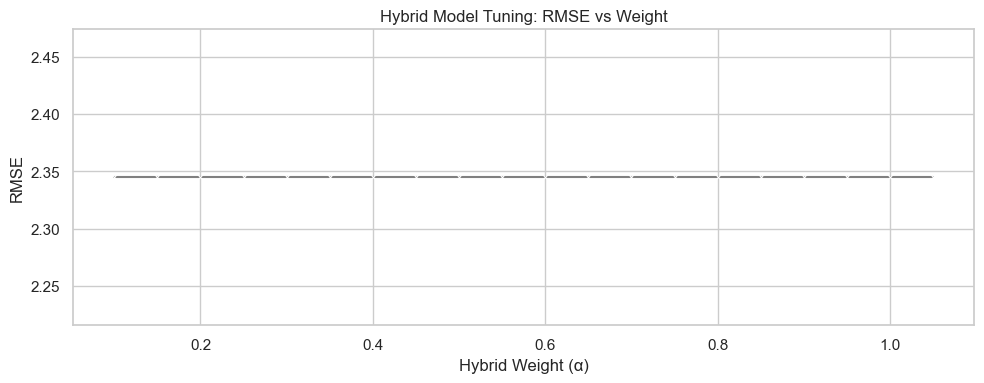

In [14]:
# Load the tuned results
df = pd.read_csv('../data/cleaned/hybrid_tuning_results_updated.csv')

# Plot Precision@10 and Recall@10 vs Weight (α)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='weight', y='precision@10', marker='o', label='Precision@10', color='#1f77b4')
sns.lineplot(data=df, x='weight', y='recall@10', marker='s', label='Recall@10', color='#2ca02c')

plt.title('Hybrid Model Tuning: Precision@10 and Recall@10 vs Weight')
plt.xlabel('Hybrid Weight (α)')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot RMSE vs Weight
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='weight', y='rmse', marker='x', color='gray')

plt.title('Hybrid Model Tuning: RMSE vs Weight')
plt.xlabel('Hybrid Weight (α)')
plt.ylabel('RMSE')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Select Best Models & Save

- **Best TF-IDF Model**
- **Best Hybrid SVD Model**

In [15]:
# Save best models
best_tfidf_params = tfidf_results.loc[tfidf_results['precision'].idxmax()]['params']
best_hybrid_weight = hybrid_results.loc[hybrid_results['precision@10'].idxmax()]['weight']
print(f"Best TF-IDF params: {best_tfidf_params}")
print(f"Best hybrid weight: {best_hybrid_weight}")

Best TF-IDF params: {'max_features': 3000, 'stop_words': 'english', 'ngram_range': (1, 1), 'min_df': 0.01, 'max_df': 0.95}
Best hybrid weight: 1.0


In [16]:
# Train and save best TF-IDF model
vectorizer = TfidfVectorizer(**eval(best_tfidf_params))
tfidf_matrix = vectorizer.fit_transform(bundle_info['content_text'])
cosine_sim = cosine_similarity(tfidf_matrix)
model_data = {
    'tfidf_vectorizer': vectorizer,
    'tfidf_matrix': tfidf_matrix,
    'cosine_sim': cosine_sim,
    'bundle_features': bundle_info,
    'bundle_indices': pd.Series(bundle_info.index, index=bundle_info['bundle_id'])
}
with open('../models/content_based_model_best.pkl', 'wb') as f:
    pickle.dump(model_data, f)

In [17]:
# Train and save best Hybid SVD model
svd_recommender = SVDHybridRecommender(n_factors=20, combine_weight=best_hybrid_weight)
svd_recommender.fit(train_matrix, content_similarity)
model_package = {
    'recommender': svd_recommender,
    'user_map': user_map,
    'item_map': item_map,
    'reverse_user_map': {idx: user_id for user_id, idx in user_map.items()},
    'reverse_item_map': {idx: bundle_id for bundle_id, idx in item_map.items()},
    'train_matrix': train_matrix,
    'content_similarity': content_similarity,
    'metrics': {
        'rmse': hybrid_results['rmse'].mean(),
        'precision@10': hybrid_results['precision@10'].mean(),
        'recall@10': hybrid_results['recall@10'].mean()
    }
}
with open('../models/svd_hybrid_model_best.pkl', 'wb') as f:
    pickle.dump(model_package, f)

C:\Users\karat\AppData\Local\Temp\ipykernel_30308\4010310445.py:3: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  svd_recommender.fit(train_matrix, content_similarity)
c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)


In [18]:
print(bundle_info.columns)

Index(['bundle_id', 'part', 'tags', 'question_count', 'part_name',
       'subject_category', 'content_text', 'video_minutes'],
      dtype='object')
